In [80]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

%matplotlib inline

In [81]:
import pandas as pd

# Step 1: Load everything without assuming a header
df = pd.read_excel('Data.xlsx', header=None)

# Step 2: Drop fully empty rows
df = df.dropna(how='all')

# Step 3: Drop fully empty columns (if any)
df = df.dropna(axis=1, how='all')

# Step 4: Reset index
df = df.reset_index(drop=True)

# Step 5: Set first row as header
df.columns = df.iloc[0]

# Step 6: Remove the header row from data
df = df[1:]

# Step 7: Reset index
df = df.reset_index(drop=True)

# Optional: clean column names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('.', '_')

df.head()

,Age,Experience,City,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Median_Income_Per_City,Income_/_Median_in_city
0,-1.774239,-1.665912,PASADENA,1.397274,-0.193366,-1.048973,-0.555468,0,1,0,0,0,-0.410787,-0.41523
1,-0.029521,-0.096321,LOS ANGELES,0.525938,-0.250586,-1.048973,-0.555468,0,1,0,0,0,-0.880547,-0.559558
2,-0.552936,-0.445119,BERKELEY,-1.216733,-0.536683,-1.048973,-0.555468,0,0,0,0,0,-0.079161,-1.18566
3,-0.90188,-0.968316,SAN FRANCISCO,-1.216733,0.436047,0.141689,-0.555468,0,0,0,0,0,0.882823,-0.073356
4,-0.90188,-1.055515,NORTHRIDGE,1.397274,-0.536683,0.141689,-0.555468,0,0,0,0,1,-0.574035,-0.433551


In [82]:
df.shape

(5000, 14)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      5000 non-null   object
 1   Experience               5000 non-null   object
 2   City                     5000 non-null   object
 3   Family                   5000 non-null   object
 4   CCAvg                    5000 non-null   object
 5   Education                5000 non-null   object
 6   Mortgage                 5000 non-null   object
 7   Personal_Loan            5000 non-null   object
 8   Securities_Account       5000 non-null   object
 9   CD_Account               5000 non-null   object
 10  Online                   5000 non-null   object
 11  CreditCard               5000 non-null   object
 12  Median_Income_Per_City   5000 non-null   object
 13  Income_/_Median_in_city  5000 non-null   object
dtypes: object(14)
memory usage: 547.0+ KB


In [84]:
# Convert all columns except 'City' to numeric
numeric_cols = df.columns.drop('City')
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Check again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   float64
 1   Experience               5000 non-null   float64
 2   City                     5000 non-null   object 
 3   Family                   5000 non-null   float64
 4   CCAvg                    5000 non-null   float64
 5   Education                5000 non-null   float64
 6   Mortgage                 5000 non-null   float64
 7   Personal_Loan            5000 non-null   int64  
 8   Securities_Account       5000 non-null   int64  
 9   CD_Account               5000 non-null   int64  
 10  Online                   5000 non-null   int64  
 11  CreditCard               5000 non-null   int64  
 12  Median_Income_Per_City   5000 non-null   float64
 13  Income_/_Median_in_city  5000 non-null   float64
dtypes: float64(8), int64(5),

In [85]:
df.duplicated().sum()

0

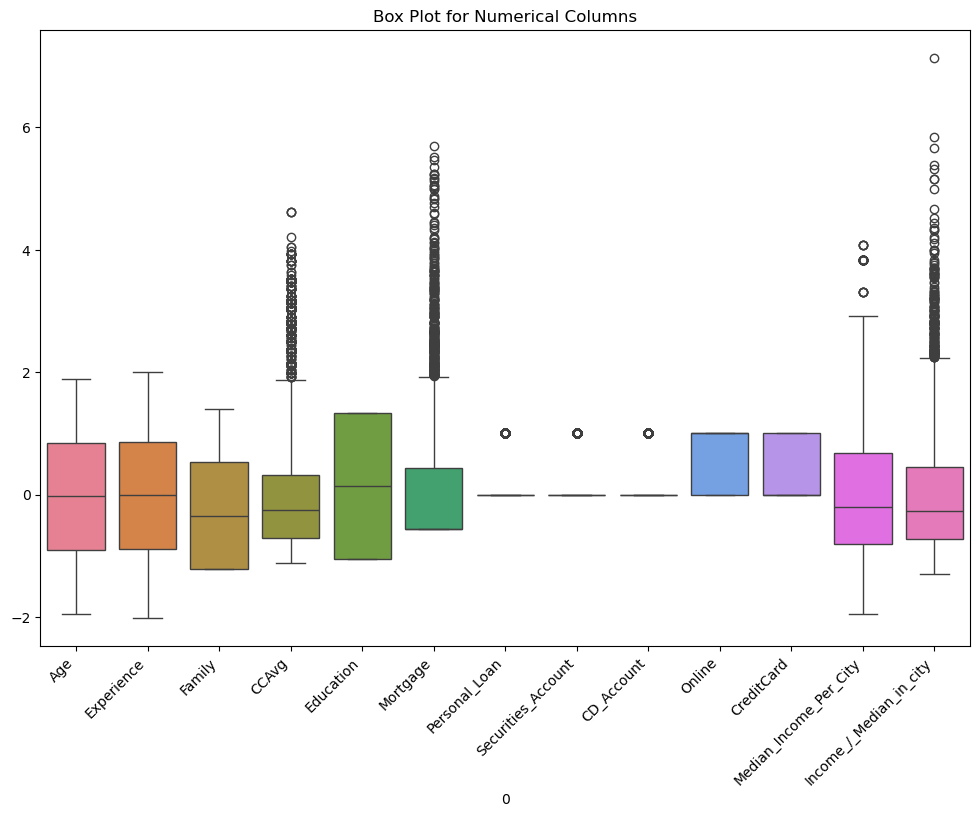

In [86]:
numerical_columns = df.select_dtypes(include=['number'])


plt.figure(figsize=(12, 8))
sns.boxplot(data=numerical_columns)
plt.title("Box Plot for Numerical Columns")


plt.xticks(rotation=45, ha="right")


plt.show()

In [87]:
df.columns = [col.replace('.', '_') for col in df.columns]

In [88]:
X = df.drop(['Personal_Loan', 'City'], axis=1)  # drop target and categorical column
y = df['Personal_Loan']

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# pipeline with different classifiers
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier())
])

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC())
])

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])

# fitting the pipelines
pipeline_rf.fit(X_train, y_train)
pipeline_svm.fit(X_train, y_train)
pipeline_lr.fit(X_train, y_train)

# predictions
y_pred_rf = pipeline_rf.predict(X_test)
y_pred_svm = pipeline_svm.predict(X_test)
y_pred_lr = pipeline_lr.predict(X_test)

# performance
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Random Forest Accuracy:", accuracy_rf)
print("SVM Accuracy:", accuracy_svm)
print("Logistic Regression Accuracy:", accuracy_lr)

Random Forest Accuracy: 0.975
SVM Accuracy: 0.97
Logistic Regression Accuracy: 0.945


In [90]:
# hyperparameter grids for RandomForestClassifier
param_grid_rf = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}


pipeline_rf_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=5))
])

# cross-validation and hyperparameter tuning
pipeline_rf_cv.fit(X_train, y_train)

# best hyperparameters and predictions
y_pred_rf_cv = pipeline_rf_cv.predict(X_test)


accuracy_rf_cv = accuracy_score(y_test, y_pred_rf_cv)
print("Random Forest Accuracy (with CV):", accuracy_rf_cv)


best_params_rf = pipeline_rf_cv.named_steps['classifier'].best_params_
print("\nBest Hyperparameters for RandomForestClassifier:")
print(best_params_rf)

Random Forest Accuracy (with CV): 0.98

Best Hyperparameters for RandomForestClassifier:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [91]:
classification_rep = classification_report(y_test, y_pred_rf_cv)
print("Classification Report:\n", classification_rep)

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       895
           1       0.98      0.83      0.90       105

    accuracy                           0.98      1000
   macro avg       0.98      0.91      0.94      1000
weighted avg       0.98      0.98      0.98      1000



In [92]:
pipeline_rf_cv.fit(X_train, y_train)


y_pred_train = pipeline_rf_cv.predict(X_train)


y_pred_test = pipeline_rf_cv.predict(X_test)


accuracy_train = accuracy_score(y_train, y_pred_train)
print("Training Set Accuracy:", accuracy_train)


accuracy_test = accuracy_score(y_test, y_pred_test)
print("Test Set Accuracy:", accuracy_test)

Training Set Accuracy: 0.99675
Test Set Accuracy: 0.977


In [93]:
for actual, predicted in zip(y_test, y_pred_rf_cv):
    print(f"Actual: {actual}, Predicted: {predicted}")

# performance eval
accuracy_rf = accuracy_score(y_test, y_pred_rf_cv)
print("Random Forest Accuracy:", accuracy_rf)

Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predi